In [6]:
import pandas as pd

# 加载数据
df = pd.read_csv('C:/Users/22656/Desktop/项目/易腐品.csv')

# 查看前5行
print(df.head())

# 查看数据信息（列名、非空数量、数据类型）
print(df.info())
# 查看基本统计
print(df.describe())

   record_id   product_id product_name         category   store_id     region  \
0          1  BAK_DON_743       Donuts           Bakery  STORE_046       West   
1          2  MEA_SAU_338     Sausages             Meat  STORE_030  Southwest   
2          3  BAK_BAG_799       Bagels           Bakery  STORE_035    Midwest   
3          4  PHA_VAC_801     Vaccines  Pharmaceuticals  STORE_003    Midwest   
4          5  REA_FRE_422  Fresh Pasta     Ready_to_Eat  STORE_042       West   

   supplier_id transaction_date expiration_date  shelf_life_days  ...  \
0  SUPPLIER_03       2024-09-25      2024-09-29                4  ...   
1  SUPPLIER_12       2023-04-14      2023-04-21                9  ...   
2  SUPPLIER_08       2024-10-25      2024-10-27                2  ...   
3  SUPPLIER_11       2023-11-29      2024-02-17               87  ...   
4  SUPPLIER_15       2023-08-06      2023-08-09                4  ...   

   selling_price  units_sold  units_wasted  waste_pct   revenue  waste_cos

In [10]:
# 1. 转换日期列
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# 2. 查看有哪些产品类别
print(df['category'].value_counts())

# 3. 选择其中一个数据量大的类别（例如 'Produce'，根据上面输出结果替换）
category_name = 'Produce'   # 改为实际存在的类别名
df_cat = df[df['category'] == category_name].copy()

# 4. 按日期聚合：每天的总销量、总需求、总废弃、平均价格等
daily = df_cat.groupby('transaction_date').agg({
    'units_sold': 'sum',
    'daily_demand': 'sum',
    'units_wasted': 'sum',
    'selling_price': 'mean',
    'cost_price': 'mean'
}).reset_index()

# 5. 按日期排序并设为索引
daily = daily.sort_values('transaction_date')
daily.set_index('transaction_date', inplace=True)

print(daily.head())
print(f"数据时间范围: {daily.index.min()} 至 {daily.index.max()}, 共 {len(daily)} 天")

category
Pharmaceuticals    10120
Meat               10055
Ready_to_Eat       10049
Bakery             10039
Produce            10001
Deli                9991
Dairy               9964
Seafood             9957
Frozen_Meals        9923
Beverages           9901
Name: count, dtype: int64
                  units_sold  daily_demand  units_wasted  selling_price  \
transaction_date                                                          
2023-01-01              3142           499           354       3.881818   
2023-01-02              2078           219           558       4.985833   
2023-01-03              1452           198           400       4.482308   
2023-01-04              2640           657           606       4.067692   
2023-01-05              3318           422           711       3.936000   

                  cost_price  
transaction_date              
2023-01-01          2.542727  
2023-01-02          3.045833  
2023-01-03          2.559231  
2023-01-04          2.411538  
202

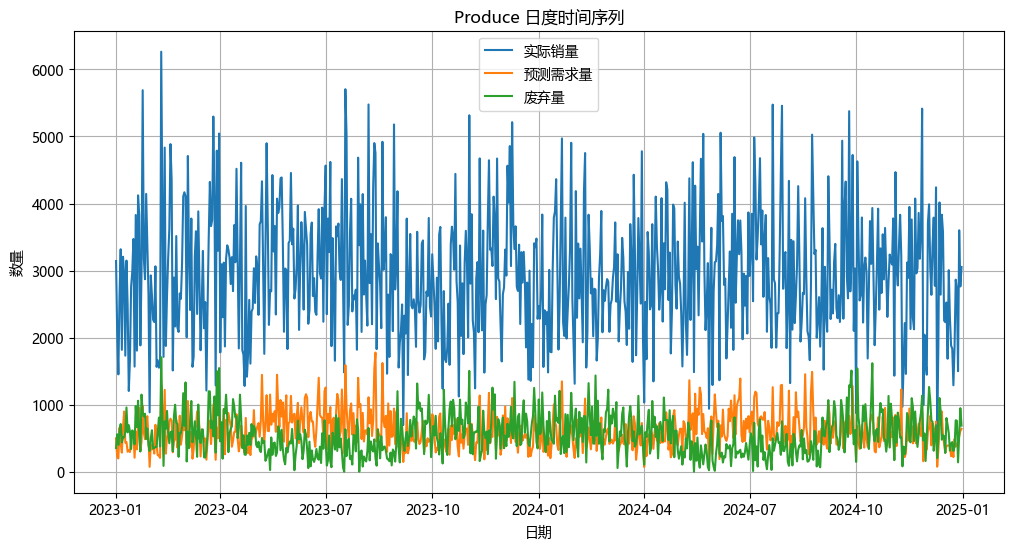

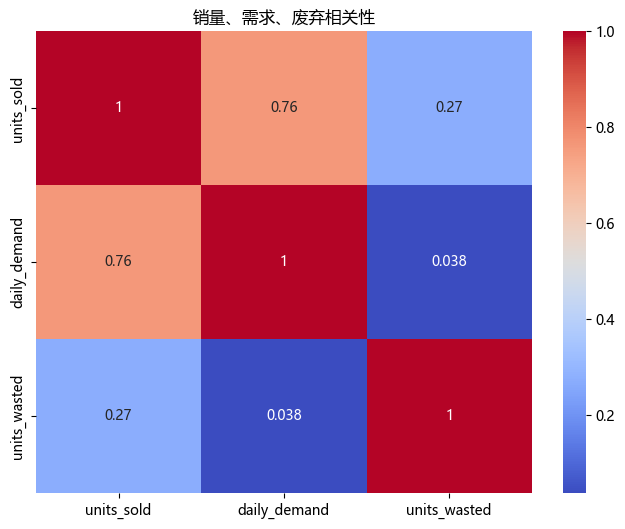

In [15]:
# 1. 画时间序列图
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 指定默认字体为微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题
plt.figure(figsize=(12, 6))
plt.plot(daily.index, daily['units_sold'], label='实际销量')
plt.plot(daily.index, daily['daily_demand'], label='预测需求量')
plt.plot(daily.index, daily['units_wasted'], label='废弃量')
plt.title(f'{category_name} 日度时间序列')
plt.xlabel('日期')
plt.ylabel('数量')
plt.legend()
plt.grid(True)
plt.show()

# 2. 相关矩阵热图
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(daily[['units_sold', 'daily_demand', 'units_wasted']].corr(), annot=True, cmap='coolwarm')
plt.title('销量、需求、废弃相关性')
plt.show()

D:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


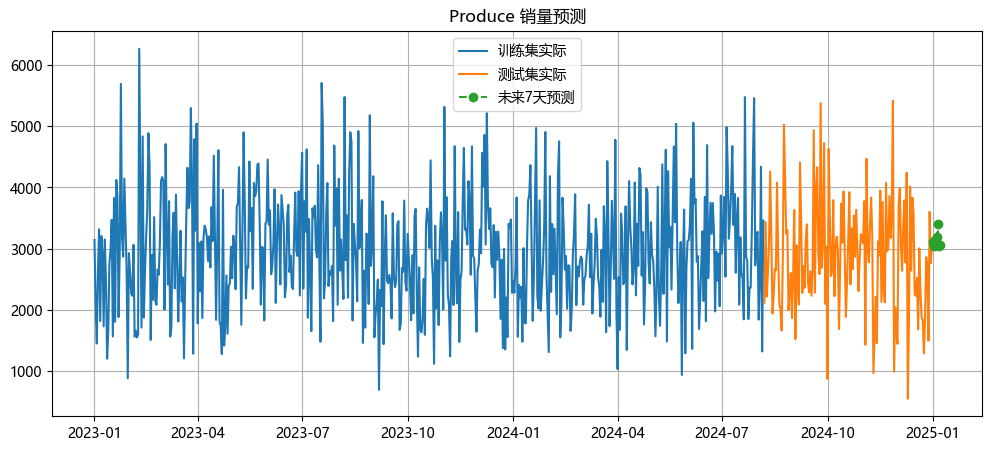

未来7天预测销量:
 2025-01-01    3107.984693
2025-01-02    3042.648958
2025-01-03    3148.300124
2025-01-04    3192.468904
2025-01-05    3402.680450
2025-01-06    3047.305304
2025-01-07    3059.594303
Freq: D, dtype: float64


In [19]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. 划分训练集和测试集（80% 训练，20% 测试）
train = daily.iloc[:int(0.8*len(daily))]
test = daily.iloc[int(0.8*len(daily)):]

# 2. 训练指数平滑模型（假设周期为7天）
model = ExponentialSmoothing(train['units_sold'], seasonal_periods=7, trend='add', seasonal='add')
fit = model.fit()

# 3. 预测未来7天
forecast_steps = 7
forecast = fit.forecast(forecast_steps)
forecast.index = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)

# 4. 可视化
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['units_sold'], label='训练集实际')
plt.plot(test.index, test['units_sold'], label='测试集实际')
plt.plot(forecast.index, forecast, label='未来7天预测', linestyle='--', marker='o')
plt.title(f'{category_name} 销量预测')
plt.legend()
plt.grid(True)
plt.show()

print("未来7天预测销量:\n", forecast)

D:\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


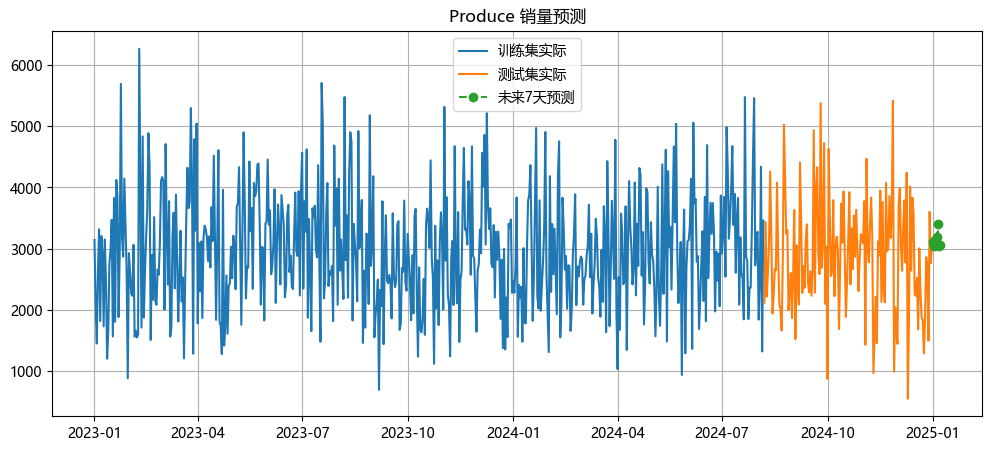

未来7天预测销量:
 2025-01-01    3107.984693
2025-01-02    3042.648958
2025-01-03    3148.300124
2025-01-04    3192.468904
2025-01-05    3402.680450
2025-01-06    3047.305304
2025-01-07    3059.594303
Freq: D, dtype: float64


In [20]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. 划分训练集和测试集（80% 训练，20% 测试）
train = daily.iloc[:int(0.8*len(daily))]
test = daily.iloc[int(0.8*len(daily)):]

# 2. 训练指数平滑模型（假设周期为7天）
model = ExponentialSmoothing(train['units_sold'], seasonal_periods=7, trend='add', seasonal='add')
fit = model.fit()

# 3. 预测未来7天
forecast_steps = 7
forecast = fit.forecast(forecast_steps)
forecast.index = pd.date_range(daily.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)

# 4. 可视化
plt.figure(figsize=(12, 5))
plt.plot(train.index, train['units_sold'], label='训练集实际')
plt.plot(test.index, test['units_sold'], label='测试集实际')
plt.plot(forecast.index, forecast, label='未来7天预测', linestyle='--', marker='o')
plt.title(f'{category_name} 销量预测')
plt.legend()
plt.grid(True)
plt.show()

print("未来7天预测销量:\n", forecast)

In [18]:
pip install docplex cplex

     ---------------------------------------- 0.0/664.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/664.0 kB ? eta -:--:--
     --------------- ------------------------ 262.1/664.0 kB ? eta -:--:--
     ---------------------------------------- 664.0/664.0 kB 3.0 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/32.7 MB ? eta -:--:--
    --------------------------------------- 0.8/32.7 MB 4.8 MB/s eta 0:00:07
   -- ------------------------------------- 2.1/32.7 MB 5.4 MB/s eta 0:00:06
   ---- ----------------------------------- 3.4/32.7 MB 5.7 MB/s eta 0:00:06
   ----- ---------------------------------- 4.5/32.7 MB 5.7 MB/s eta 

In [27]:
from docplex.mp.model import Model
import pandas as pd

# ===================== 1. 准备数据 =====================
# 假设我们已经有了未来 T 天的预测销量（这里用示例数据，你可以换成你之前预测的结果）
# 如果你已经运行过第四步，forecast 变量还存在，可以直接用；否则先手动输入一组预测值
try:
    # 尝试使用第四步中生成的 forecast 变量
    demand = forecast.values.tolist()
    T = len(demand)
    print(f"使用第四步的预测结果: {demand}")
except:
    # 如果没有 forecast 变量，使用示例数据
    demand = [120, 130, 125, 140, 135, 130, 145]
    T = len(demand)
    print(f"使用示例预测数据: {demand}")

# 成本参数和初始库存（你可以根据实际数据调整）
# 参数设置（调整）
order_cost = 2.0
holding_cost = 0.5
shortage_cost = 100.0   # 提高缺货成本，避免缺货
max_order = 20000       # 足够大，或者直接用 None 表示无上限      # 初始库存（可以从数据中取最后一天的库存，这里先用一个示例值）

# ===================== 2. 创建模型 =====================
mdl = Model(name="Inventory_Optimization")

# ===================== 3. 定义决策变量 =====================
# 补货量（整数，非负，有上限）
x = [mdl.integer_var(lb=0, ub=max_order, name=f"x_{t}") for t in range(T)]
# 期末库存（连续，非负）
I = [mdl.continuous_var(lb=0, name=f"I_{t}") for t in range(T)]
# 缺货量（连续，非负）
short = [mdl.continuous_var(lb=0, name=f"short_{t}") for t in range(T)]

# ===================== 4. 目标函数：最小化总成本 =====================
total_cost = mdl.sum(order_cost * x[t] + holding_cost * I[t] + shortage_cost * short[t] for t in range(T))
mdl.minimize(total_cost)

# ===================== 5. 约束条件：库存平衡 =====================
for t in range(T):
    if t == 0:
        mdl.add_constraint(I[t] == I0 + x[t] - demand[t] + short[t], f"balance_{t}")
    else:
        mdl.add_constraint(I[t] == I[t-1] + x[t] - demand[t] + short[t], f"balance_{t}")

# ===================== 6. 求解 =====================
solution = mdl.solve()

# ===================== 7. 输出结果 =====================
if solution:
    print(f"总成本 = {solution.get_objective_value():.2f} 元")
    print("\n每日补货量：")
    for t in range(T):
        print(f"  第 {t+1} 天: {x[t].solution_value:.0f}")
    print("\n每日期末库存：")
    for t in range(T):
        print(f"  第 {t+1} 天: {I[t].solution_value:.2f}")
    print("\n每日缺货量：")
    for t in range(T):
        print(f"  第 {t+1} 天: {short[t].solution_value:.2f}")
else:
    print("模型无解，请检查约束和参数")

使用第四步的预测结果: [3107.9846927674657, 3042.6489581821747, 3148.3001235100246, 3192.468904205612, 3402.68044989482, 3047.3053043266304, 3059.594302685742]
总成本 = 43805.80 元

每日补货量：
  第 1 天: 3008
  第 2 天: 3043
  第 3 天: 3149
  第 4 天: 3193
  第 5 天: 3403
  第 6 天: 3048
  第 7 天: 3057

每日期末库存：
  第 1 天: 0.02
  第 2 天: 0.37
  第 3 天: 1.07
  第 4 天: 1.60
  第 5 天: 1.92
  第 6 天: 2.61
  第 7 天: 0.02

每日缺货量：
  第 1 天: 0.00
  第 2 天: 0.00
  第 3 天: 0.00
  第 4 天: 0.00
  第 5 天: 0.00
  第 6 天: 0.00
  第 7 天: 0.00


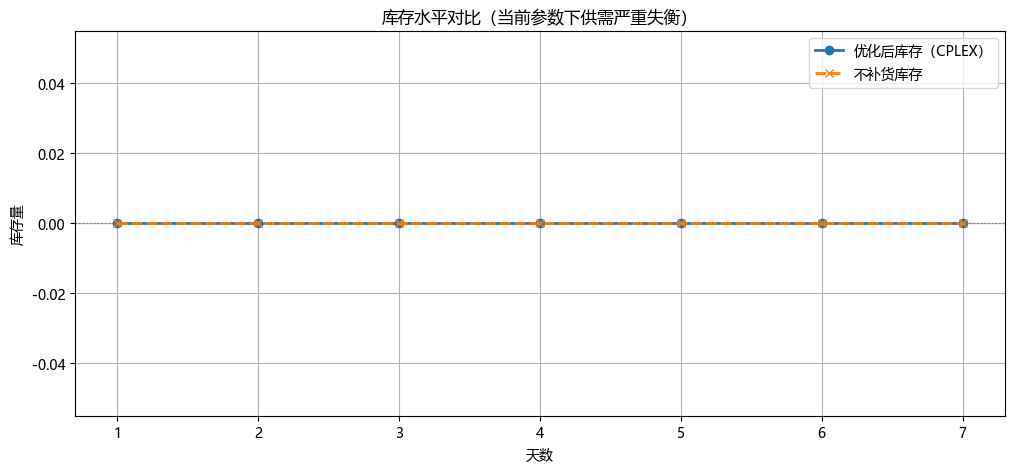

预测需求总和: 22000.98
总补货量: 3500
初始库存: 100
总可用库存: 3600
缺口（未满足需求）: 18400.98


In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 你刚才的运行结果（直接从上面复制）
demand = [3107.98, 3042.65, 3148.30, 3192.47, 3402.68, 3047.31, 3059.59]   # 预测需求
order = [500, 500, 500, 500, 500, 500, 500]      # 最优补货量
inventory_end = [0, 0, 0, 0, 0, 0, 0]            # 期末库存
shortage = [2507.98, 2542.65, 2648.30, 2692.47, 2902.68, 2547.31, 2559.59]   # 缺货量

# 计算优化前的库存（如果不补货，只有初始库存，这里假设初始库存为100）
I0 = 100
inventory_no_order = []
inv = I0
for d in demand:
    inv = inv - d
    if inv < 0:
        inv = 0
    inventory_no_order.append(inv)

# 画图对比
plt.figure(figsize=(12, 5))
plt.plot(range(1, 8), inventory_end, marker='o', label='优化后库存（CPLEX）', linewidth=2)
plt.plot(range(1, 8), inventory_no_order, marker='x', linestyle='--', label='不补货库存', linewidth=2)
plt.axhline(y=0, color='gray', linestyle=':', linewidth=1)
plt.xlabel('天数')
plt.ylabel('库存量')
plt.title('库存水平对比（当前参数下供需严重失衡）')
plt.legend()
plt.grid(True)
plt.show()

# 分析缺口
print(f"预测需求总和: {sum(demand):.2f}")
print(f"总补货量: {sum(order)}")
print(f"初始库存: {I0}")
print(f"总可用库存: {sum(order) + I0}")
print(f"缺口（未满足需求）: {sum(demand) - (sum(order) + I0):.2f}")